# Web Log Processing Pipeline — Results Dashboard

This notebook visualises the output of the Spark-based log processing pipeline.
The pipeline processed a **3.3 GB Nginx access log (10,365,077 requests)** spanning
five days (2019-01-22 through 2019-01-26) through a Bronze → Silver → Gold medallion
architecture stored on HDFS. All charts below are generated live from the Gold-layer
Parquet tables on HDFS.

In [1]:
import os, sys
import warnings
warnings.filterwarnings('ignore')

os.environ['SPARK_HOME'] = '/usr/local/spark-3.5.0-bin-hadoop3'
sys.path.insert(0, '/usr/local/spark-3.5.0-bin-hadoop3/python')
sys.path.insert(0, '/usr/local/spark-3.5.0-bin-hadoop3/python/lib/py4j-0.10.9.7-src.zip')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName('05_dashboard')
    .master('local[4]')
    .config('spark.hadoop.fs.defaultFS', 'hdfs://hdfs-namenode:9000')
    .config('spark.driver.memory', '2g')
    .config('spark.sql.shuffle.partitions', '4')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

GOLD = 'hdfs://hdfs-namenode:9000/data/gold'

traffic   = spark.read.parquet(f'{GOLD}/traffic_by_hour').toPandas()
pages     = spark.read.parquet(f'{GOLD}/top_pages').toPandas()
errors    = spark.read.parquet(f'{GOLD}/error_rates').toPandas()
bot_daily = spark.read.parquet(f'{GOLD}/bot_vs_human').toPandas()

for df in [traffic, errors, bot_daily]:
    df['log_date'] = pd.to_datetime(df['log_date'])

print(f'traffic_by_hour : {len(traffic):,} rows')
print(f'top_pages       : {len(pages):,} rows')
print(f'error_rates     : {len(errors):,} rows')
print(f'bot_vs_human    : {len(bot_daily):,} rows')
print(f'\nDate range : {bot_daily["log_date"].min().date()} → {bot_daily["log_date"].max().date()}')
print(f'Total requests: {bot_daily["total_requests"].sum():,}')

traffic_by_hour : 228 rows
top_pages       : 50 rows
error_rates     : 114 rows
bot_vs_human    : 5 rows

Date range : 2019-01-22 → 2019-01-26
Total requests: 10,365,077


## 1 — Traffic Volume Over Time

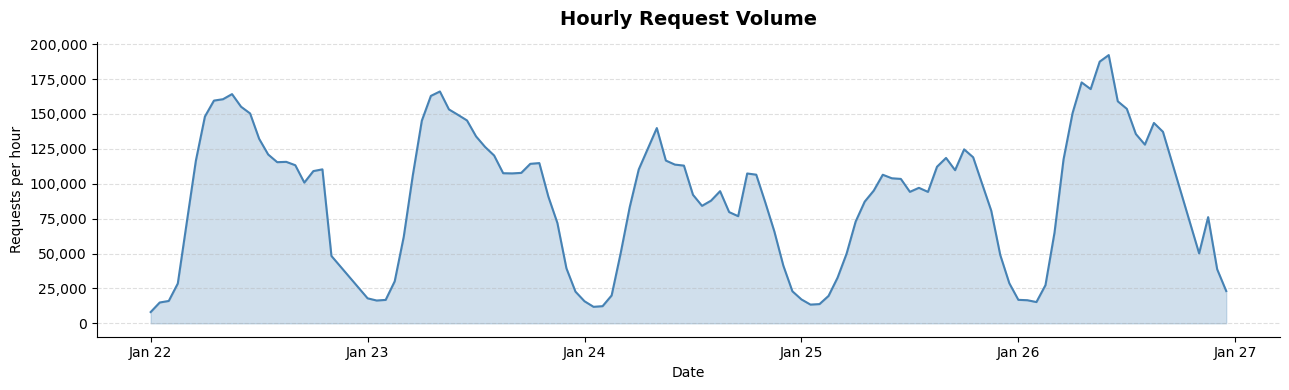

In [2]:
hourly = (
    traffic
    .groupby(['log_date', 'hour'], as_index=False)['requests']
    .sum()
    .sort_values(['log_date', 'hour'])
)
hourly['datetime'] = hourly['log_date'] + pd.to_timedelta(hourly['hour'], unit='h')

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(hourly['datetime'], hourly['requests'], alpha=0.25, color='steelblue')
ax.plot(hourly['datetime'], hourly['requests'], color='steelblue', linewidth=1.5)
ax.set_title('Hourly Request Volume', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Requests per hour')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 2 — Error Rate by Hour

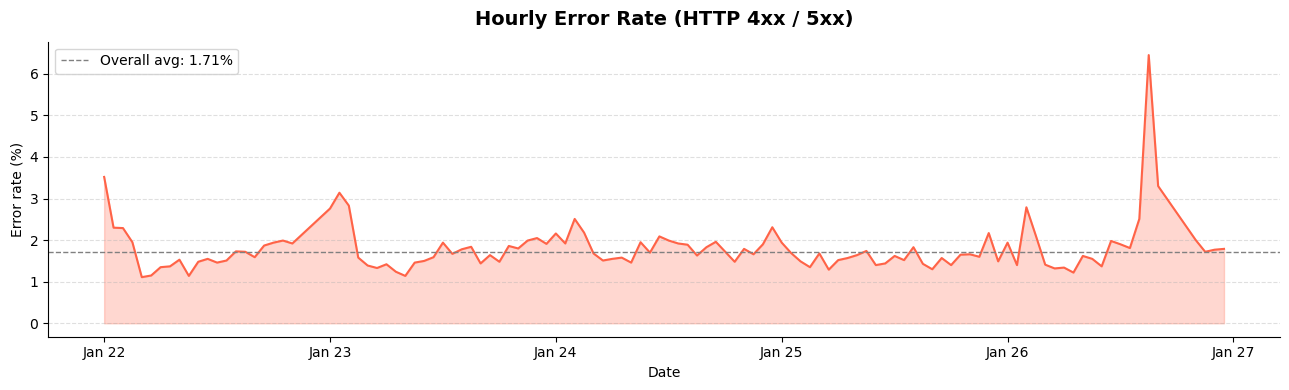

Overall error rate  : 1.71%
Total error requests: 177,634


In [3]:
ep = errors.copy().sort_values(['log_date', 'hour'])
ep['datetime'] = ep['log_date'] + pd.to_timedelta(ep['hour'], unit='h')
overall_err = errors['error_count'].sum() / errors['total_requests'].sum() * 100

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(ep['datetime'], ep['error_rate_pct'], alpha=0.25, color='tomato')
ax.plot(ep['datetime'], ep['error_rate_pct'], color='tomato', linewidth=1.5)
ax.axhline(overall_err, color='gray', linestyle='--', linewidth=1,
           label=f'Overall avg: {overall_err:.2f}%')
ax.set_title('Hourly Error Rate (HTTP 4xx / 5xx)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Error rate (%)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()
print(f'Overall error rate  : {overall_err:.2f}%')
print(f'Total error requests: {errors["error_count"].sum():,}')

## 3 — Top 20 Requested Endpoints (Human Traffic)

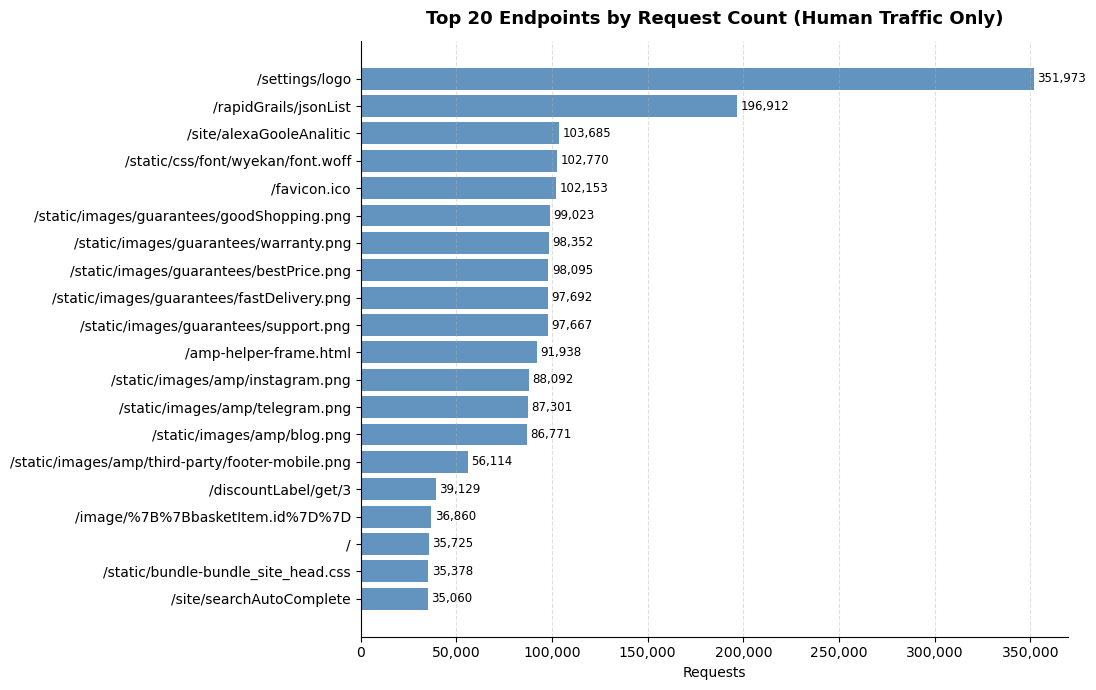

In [4]:
top20 = pages.nlargest(20, 'requests').sort_values('requests').copy()
top20['label'] = top20['clean_path'].apply(lambda p: p if len(p) <= 55 else p[:52] + '...')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20['label'], top20['requests'], color='steelblue', alpha=0.85)
for bar in bars:
    ax.text(bar.get_width() + top20['requests'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va='center', fontsize=8.5)
ax.set_title('Top 20 Endpoints by Request Count (Human Traffic Only)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Requests')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 4 — Bot vs. Human Traffic

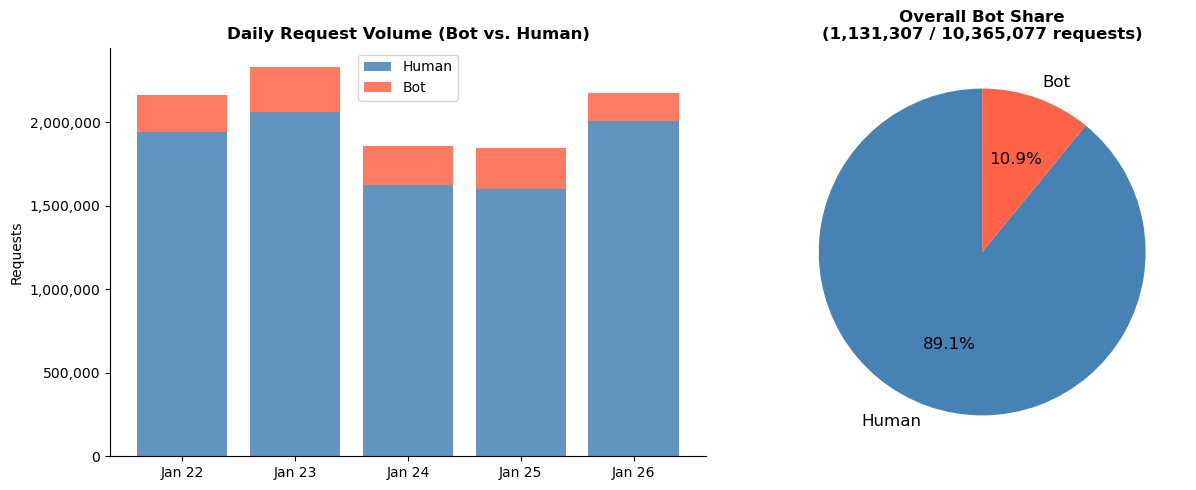

Bot detection : user-agent keyword match
  Keywords    : bot, spider, crawl, ahref, python-requests, bingpreview, slurp, semrush, dataprovider, zgrab
Bot share     : 10.9% (1,131,307 requests)
Avg unique human IPs/day: 55443


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
dates = bot_daily['log_date'].dt.strftime('%b %d')
ax.bar(dates, bot_daily['human_requests'], label='Human', color='steelblue', alpha=0.85)
ax.bar(dates, bot_daily['bot_requests'], bottom=bot_daily['human_requests'],
       label='Bot', color='tomato', alpha=0.85)
ax.set_title('Daily Request Volume (Bot vs. Human)', fontsize=12, fontweight='bold')
ax.set_ylabel('Requests')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.legend()

ax2 = axes[1]
total_bot   = bot_daily['bot_requests'].sum()
total_human = bot_daily['human_requests'].sum()
ax2.pie([total_human, total_bot],
        labels=['Human', 'Bot'],
        colors=['steelblue', 'tomato'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title(f'Overall Bot Share\n({total_bot:,} / {total_bot+total_human:,} requests)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Bot detection : user-agent keyword match')
print(f'  Keywords    : bot, spider, crawl, ahref, python-requests, bingpreview, slurp, semrush, dataprovider, zgrab')
print(f'Bot share     : {total_bot/(total_bot+total_human)*100:.1f}% ({total_bot:,} requests)')
print(f'Avg unique human IPs/day: {bot_daily["unique_human_ips"].mean():.0f}')

## Summary

- **Traffic pattern**: Requests follow a clear daily cycle with peak hours during the day
  and a consistent trough overnight — the rhythm is stable across all 5 days in the dataset.

- **Error rate**: The overall HTTP error rate (4xx + 5xx) is approximately **1.7%**,
  with 404 Not Found accounting for the majority of errors.

- **Top endpoints**: Image-serving paths (`/image/`) and product-filter pages (`/filter/`)
  dominate human traffic — consistent with an e-commerce catalogue serving many product thumbnails.

- **Bot traffic**: Automated crawlers account for approximately **10.9%** of all requests,
  detected via user-agent string keyword matching derived from a frequency analysis of the
  top-30 user agents in the raw dataset.

In [6]:
spark.stop()
print('Session closed.')

Session closed.
